### 1. Experiment 1: correction and no correction

In [ ]:
results = [
    {"metric": "Faithfulness", "k": 1,  "ocr": 68.32, "no_ocr": 72.58},
    {"metric": "Faithfulness", "k": 10, "ocr": 78.70, "no_ocr": 81.47},

    {"metric": "Answer Relevancy", "k": 1,  "ocr": 37.10, "no_ocr": 35.31},
    {"metric": "Answer Relevancy", "k": 10, "ocr": 53.30, "no_ocr": 52.52},

    {"metric": "Answer Correctness", "k": 1,  "ocr": 29.91, "no_ocr": 28.81},
    {"metric": "Answer Correctness", "k": 10, "ocr": 40.49, "no_ocr": 39.93},

    {"metric": "Context Relevance", "k": 1,  "ocr": 44.27, "no_ocr": 42.56},
    {"metric": "Context Relevance", "k": 10, "ocr": 62.60, "no_ocr": 61.07},

    {"metric": "LLM Correctness", "k": 1,  "ocr": 31.68, "no_ocr": 30.53},
    {"metric": "LLM Correctness", "k": 10, "ocr": 49.62, "no_ocr": 49.24},

    {"metric": "Chunk Relevance", "k": 1,  "ocr": 32.06, "no_ocr": 30.53},
    {"metric": "Chunk Relevance", "k": 10, "ocr": 12.52, "no_ocr": 13.21},

    {"metric": "NDCG", "k": 1,  "ocr": 32.06, "no_ocr": 30.99},
    {"metric": "NDCG", "k": 10, "ocr": 52.13, "no_ocr": 52.97},
]


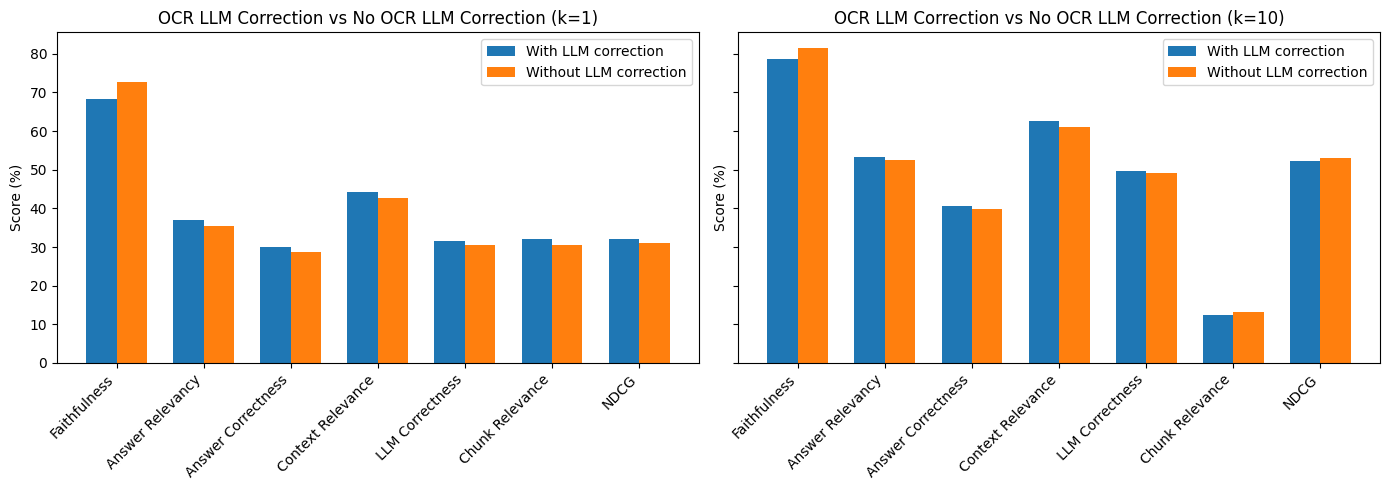

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.DataFrame(results)
metrics = df["metric"].unique()
x = np.arange(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, k in zip(axes, [1, 10]):
    subset = df[df["k"] == k]

    ax.bar(x - width/2, subset["ocr"], width, label="With LLM correction")
    ax.bar(x + width/2, subset["no_ocr"], width, label="Without LLM correction")

    ax.set_title(f"OCR LLM Correction vs No OCR LLM Correction (k={k})")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=45, ha="right")
    ax.set_ylabel("Score (%)")
    ax.legend()

plt.tight_layout()
plt.show()


### 2. Experiment 2: Reranker

In [ ]:
reranker_results = [
    # k = 1
    {"k": 1, "reranker": "No",  "Faith": 72.58, "AnsRel": 35.31, "AnsCorr": 28.81,
     "CtxRel": 42.56, "LLMCorr": 30.53, "ChunkRel": 30.53, "NDCG": 30.99},
    {"k": 1, "reranker": "Yes", "Faith": 67.95, "AnsRel": 48.93, "AnsCorr": 35.43,
     "CtxRel": 56.87, "LLMCorr": 39.31, "ChunkRel": 47.44, "NDCG": 44.73},

    # k = 3
    {"k": 3, "reranker": "No",  "Faith": 75.20, "AnsRel": 52.38, "AnsCorr": 28.29,
     "CtxRel": 55.34, "LLMCorr": 44.66, "ChunkRel": 23.15, "NDCG": 51.55},
    {"k": 3, "reranker": "Yes", "Faith": 80.08, "AnsRel": 52.01, "AnsCorr": 39.06,
     "CtxRel": 62.21, "LLMCorr": 47.33, "ChunkRel": 27.48, "NDCG": 60.05},

    # k = 5
    {"k": 5, "reranker": "No",  "Faith": 78.04, "AnsRel": 53.10, "AnsCorr": 40.52,
     "CtxRel": 57.06, "LLMCorr": 46.56, "ChunkRel": 19.39, "NDCG": 52.21},
    {"k": 5, "reranker": "Yes", "Faith": 80.40, "AnsRel": 51.94, "AnsCorr": 38.84,
     "CtxRel": 65.08, "LLMCorr": 45.42, "ChunkRel": 21.68, "NDCG": 60.45},

    # k = 10
    {"k": 10, "reranker": "No",  "Faith": 81.47, "AnsRel": 52.52, "AnsCorr": 39.93,
     "CtxRel": 61.07, "LLMCorr": 49.24, "ChunkRel": 13.21, "NDCG": 52.97},
    {"k": 10, "reranker": "Yes", "Faith": 77.63, "AnsRel": 54.64, "AnsCorr": 39.66,
     "CtxRel": 66.60, "LLMCorr": 47.44, "ChunkRel": 13.66, "NDCG": 60.85},

    # k = 20 (no reranker only)
    {"k": 20, "reranker": "No",  "Faith": 83.50, "AnsRel": 57.27, "AnsCorr": 40.53,
     "CtxRel": 61.45, "LLMCorr": 48.47, "ChunkRel": 9.08,  "NDCG": 51.32},
]


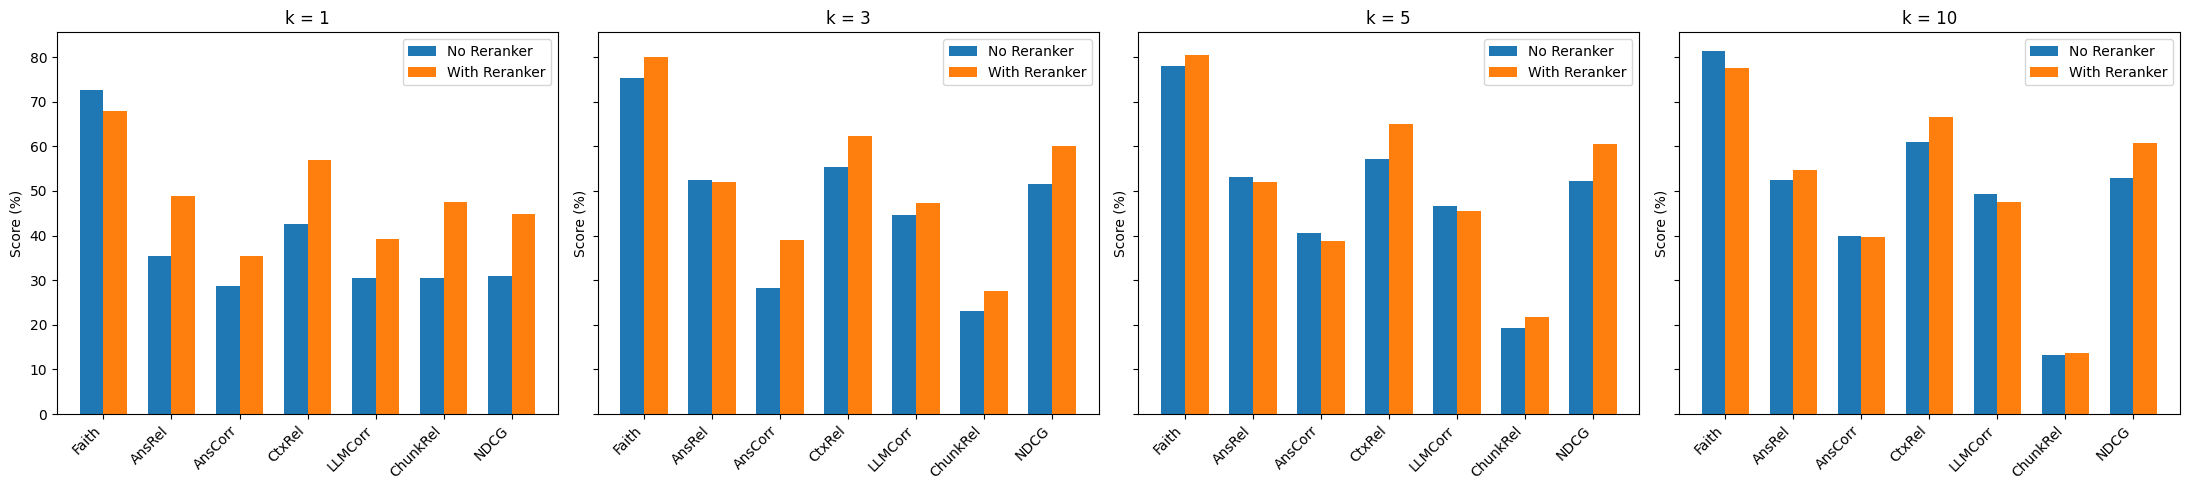

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame(reranker_results)
metrics = ["Faith", "AnsRel", "AnsCorr", "CtxRel", "LLMCorr", "ChunkRel", "NDCG"]
k_values = [1, 3, 5, 10]
x = np.arange(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)

for ax, k in zip(axes, k_values):
    subset = df[df["k"] == k]

    no_rerank = subset[subset["reranker"] == "No"]
    yes_rerank = subset[subset["reranker"] == "Yes"]

    ax.bar(x - width/2, no_rerank[metrics].values[0], width, label="No Reranker")
    ax.bar(x + width/2, yes_rerank[metrics].values[0], width, label="With Reranker")

    ax.set_title(f"k = {k}")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=45, ha="right")
    ax.set_ylabel("Score (%)")
    ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
answered_reranker = [
    {"k": 1,  "reranker": "No",  "answered": 58},
    {"k": 1,  "reranker": "Yes", "answered": 76},

    {"k": 3,  "reranker": "No",  "answered": 81},
    {"k": 3,  "reranker": "Yes", "answered": 82},

    {"k": 5,  "reranker": "No",  "answered": 83},
    {"k": 5,  "reranker": "Yes", "answered": 82},

    {"k": 10, "reranker": "No",  "answered": 84},
    {"k": 10, "reranker": "Yes", "answered": 87},
]


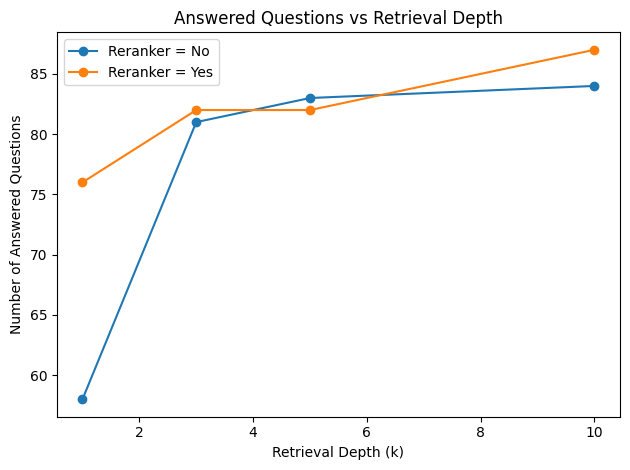

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(answered_reranker)

fig, ax = plt.subplots()

for label in ["No", "Yes"]:
    subset = df[df["reranker"] == label]
    ax.plot(subset["k"], subset["answered"], marker="o", label=f"Reranker = {label}")

ax.set_xlabel("Retrieval Depth (k)")
ax.set_ylabel("Number of Answered Questions")
ax.set_title("Answered Questions vs Retrieval Depth")
ax.legend()

plt.tight_layout()
plt.show()


### 3. Experiment 3: RAG vs BM25

In [2]:
metrics_results = [
    # k = 1
    {"k": 1, "bm25": "No",  "Faith": 72.58, "AnsRel": 35.31, "AnsCorr": 28.81,
     "CtxRel": 42.56, "LLMCorr": 30.53, "ChunkRel": 30.53, "NDCG": 30.99},
    {"k": 1, "bm25": "Yes", "Faith": 40.51, "AnsRel": 8.03,  "AnsCorr": 8.53,
     "CtxRel": 11.64, "LLMCorr": 7.63,  "ChunkRel": 7.63,  "NDCG": 7.94},

    # k = 3
    {"k": 3, "bm25": "No",  "Faith": 75.20, "AnsRel": 52.38, "AnsCorr": 28.29,
     "CtxRel": 55.34, "LLMCorr": 44.66, "ChunkRel": 23.15, "NDCG": 51.55},
    {"k": 3, "bm25": "Yes", "Faith": 55.89, "AnsRel": 9.02,  "AnsCorr": 11.48,
     "CtxRel": 13.17, "LLMCorr": 8.78,  "ChunkRel": 5.09,  "NDCG": 13.23},

    # k = 5
    {"k": 5, "bm25": "No",  "Faith": 78.04, "AnsRel": 53.10, "AnsCorr": 40.52,
     "CtxRel": 57.06, "LLMCorr": 46.56, "ChunkRel": 19.39, "NDCG": 52.21},
    {"k": 5, "bm25": "Yes", "Faith": 62.13, "AnsRel": 10.98, "AnsCorr": 12.20,
     "CtxRel": 16.41, "LLMCorr": 10.31, "ChunkRel": 4.43,  "NDCG": 14.66},
]


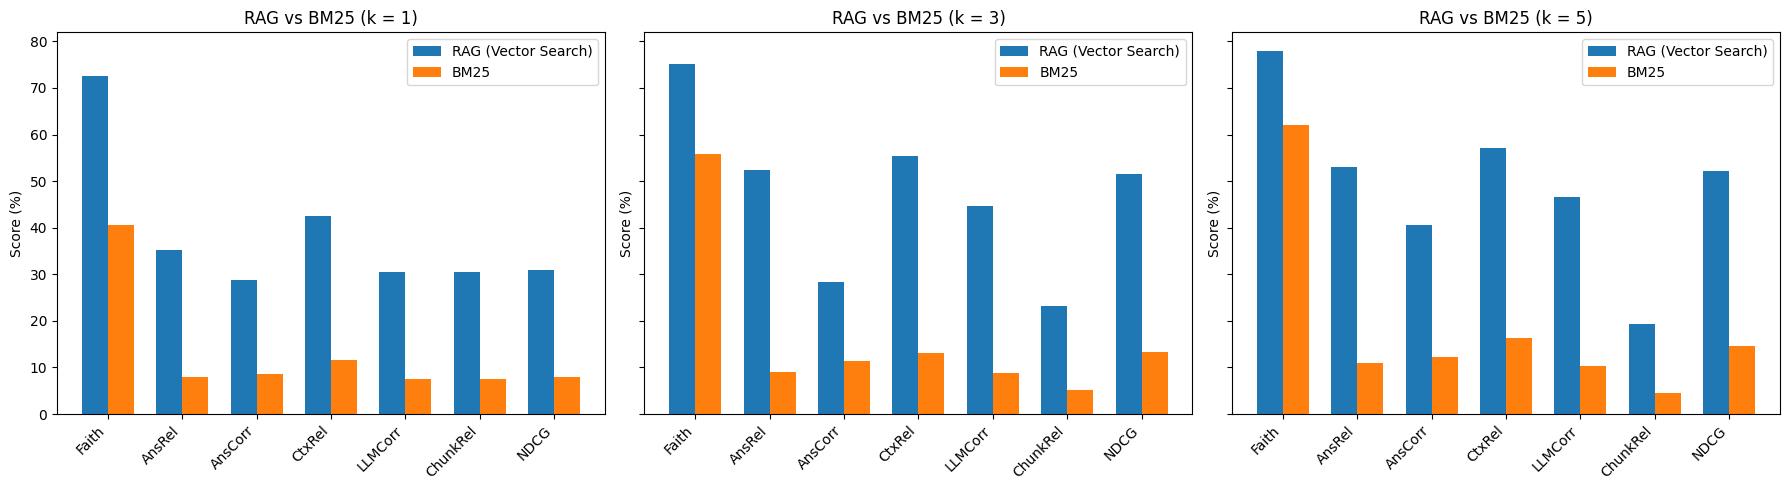

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame(metrics_results)
metrics = ["Faith", "AnsRel", "AnsCorr", "CtxRel", "LLMCorr", "ChunkRel", "NDCG"]
x = np.arange(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, k in zip(axes, [1, 3, 5]):
    subset = df[df["k"] == k]

    no_bm25 = subset[subset["bm25"] == "No"]
    yes_bm25 = subset[subset["bm25"] == "Yes"]

    ax.bar(x - width/2, no_bm25[metrics].values[0], width, label="RAG (Vector Search)")
    ax.bar(x + width/2, yes_bm25[metrics].values[0], width, label="BM25")

    ax.set_title(f"RAG vs BM25 (k = {k})")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=45, ha="right")
    ax.set_ylabel("Score (%)")
    ax.legend()

plt.tight_layout()
plt.show()


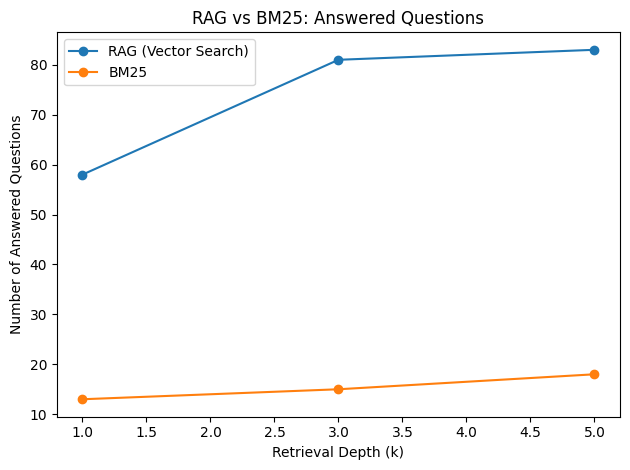

In [4]:
answered = {
    "k": [1, 3, 5],
    "RAG": [58, 81, 83],
    "BM25": [13, 15, 18],
}

df_ans = pd.DataFrame(answered)

fig, ax = plt.subplots()
ax.plot(df_ans["k"], df_ans["RAG"], marker="o", label="RAG (Vector Search)")
ax.plot(df_ans["k"], df_ans["BM25"], marker="o", label="BM25")

ax.set_xlabel("Retrieval Depth (k)")
ax.set_ylabel("Number of Answered Questions")
ax.set_title("RAG vs BM25: Answered Questions")
ax.legend()

plt.tight_layout()
plt.show()
